### Imports

In [1]:
%load_ext autoreload
%autoreload 1

import multimodal_mazes
import pickle

### Run Dist Trial

In [2]:
!python ../../multimodal_mazes/evolution/task_trials/genome_dist_trial.py

### Load Results

In [3]:
with open("genome_dist_trial.pkl", "rb") as f:
    trial_objects = pickle.load(f)

ea = trial_objects['ea']
trial_object = trial_objects['trial_object']

### Fittest Networks

In [ ]:
for genome in ea.fittest_networks:
    print(f"Genome ID: {genome.genome_id}, Fitness: {genome.fitness}, Distribution: {genome.mod_dist}")
    # genome.plot_genome()

ea.fittest_networks[0].plot_genome()

In [ ]:
ea.fittest_networks[0].modules

### Visualise Fittest Network Outputs

#### Maze

In [ ]:
if ea.task == 'maze':
    path = ea.trial_data[ea.generation-1][ea.fittest_networks[0].genome_id]['paths']

    for n in range(15):
        multimodal_mazes.plot_path(path=path[n], mz=trial_object.mazes[n], mz_goal_loc=trial_object.goal_locations[n], n_steps=len(path))

#### Image

In [ ]:
if ea.task == 'image':
    outputs = ea.trial_data[ea.generation-1][ea.fittest_networks[0].genome_id]['outputs']

    for n in range(5):
        trial_object.plot_image(trial_object.images[n], outputs[n])

### Plots

#### Fitness over Generations

In [ ]:
for generation in ea.trial_data:
    fittest_genome = ea.trial_data[generation]['fittest'][1]
    print(f"Generation: {generation}, Module Distribution: {ea.trial_data[generation]['mod_distribution']}, Fittest Fitness: {ea.trial_data[generation]['fittest'][0]}, Fittest Genome Distribution: {fittest_genome.mod_dist}")

ea.plot_fitness_over_generations()

#### Module Distribution over Generations

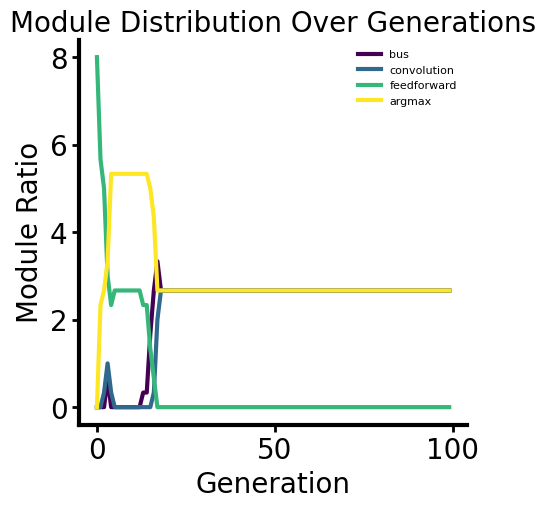

In [4]:
ea.plot_module_distribution_over_generations()

### Store Results

In [ ]:
file_to_store = "genome_dist_cross_2.pkl"

with open(file_to_store, "wb") as f:
    pickle.dump(trial_objects, f)